# Geopandas
- plan:
    - instructors want to see them putting multiple datasets together into 1 map
    - since we only have 1 dataset (census data), we can split this into multiple datasets by county, then have the students put them back together
    - once this data is put together, we can see if there is something we can do with the demographics columns that's interesting
        - original lab created a color gradient by census tract using the `pct_pov` column
    - put this on top of a reference map? (loaded from interwebz)
- questions:
    - use data found from web as example, then let the students repeat with the data we were given? or just give them all the code??
    - how much do we show vs how much do we let the students fill out?
    - questions to put into the notebook for students to answer??
    - is this just a one time deal or will they be using these skills in another assignment?

Today we are going to learn how to use python and Jupyter notebooks to work with geospatial data. We will be using the `geopandas` package, which is built on top of the `pandas` package you should already be a bit familiar with.

In [1]:
# Uncomment the following line the first time you run this lab to install geopandas.
# pip install geopandas

import pandas as pd
import geopandas as gpd
from IPython.display import display
import matplotlib.pyplot as plt

# These help the maps display nicely in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 10]

First, let's load our data and see what kind of data we are working with. Geopandas data types are GeoDataFrames and GeoSeries, which are extensions of pandas DataFrames and Series.

In [5]:
alameda = gpd.read_file('shapefiles/alameda/')
contra_costa = gpd.read_file('shapefiles/contra_costa/')
san_francisco = gpd.read_file('shapefiles/san_francisco/')

In [6]:
alameda.head()

,AFFGEOID,ALAND,ALAND_1,AWATER,AWATER_1,COUNTYFP,COUNTYFP_1,FID_1,FUNCSTAT,GEOID,...,female,male,medianage,mergeid,pct_20to64,pct_over64,pct_pov,pct_und_20,total_pop,geometry
0,1400000US06001400600,297856.0,297856.0,0.0,0.0,001,001,275.0,S,06001400600,...,1020.0,730.0,34.4,06001400600,78.2,9.8,8.3,12.0,1750.0,"POLYGON ((-122.26807 37.844136, -122.26514 37...."
1,1400000US06001400900,420877.0,420877.0,0.0,0.0,001,001,297.0,S,06001400900,...,1106.0,925.0,38.9,06001400900,71.0,7.7,12.0,21.0,2031.0,"POLYGON ((-122.285576 37.839778, -122.283186 3..."
2,1400000US06001401400,758241.0,758241.0,0.0,0.0,001,001,239.0,S,06001401400,...,2170.0,2127.0,31.3,06001401400,64.7,8.2,41.7,27.1,4297.0,"POLYGON ((-122.278611 37.826878, -122.268563 3..."
3,1400000US06001403000,352394.0,352394.0,0.0,0.0,001,001,258.0,S,06001403000,...,1445.0,1026.0,58.3,06001403000,47.9,43.8,30.2,8.3,2471.0,"POLYGON ((-122.274757 37.79883299999999, -122...."
4,1400000US06001405902,487280.0,487280.0,0.0,0.0,001,001,746.0,S,06001405902,...,1713.0,1808.0,31.5,06001405902,58.6,10.0,31.0,31.5,3521.0,"POLYGON ((-122.247175 37.789913, -122.243512 3..."


In [7]:
contra_costa.head()

,AFFGEOID,ALAND,ALAND_1,AWATER,AWATER_1,COUNTYFP,COUNTYFP_1,FID_1,FUNCSTAT,GEOID,...,female,male,medianage,mergeid,pct_20to64,pct_over64,pct_pov,pct_und_20,total_pop,geometry
0,1400000US06013303202,3676386.0,3676386.0,0.0,0.0,013,013,578.0,S,06013303202,...,3442.0,3865.0,36.9,06013303202,59.1,6.9,3.3,34.1,7307.0,"POLYGON ((-121.72346 37.945151, -121.723365 37..."
1,1400000US06013303203,6209732.0,6209732.0,0.0,0.0,013,013,351.0,S,06013303203,...,4569.0,4309.0,37.0,06013303203,51.4,13.9,5.3,34.6,8878.0,"POLYGON ((-121.744156 37.958501, -121.742401 3..."
2,1400000US06013313206,1728163.0,1728163.0,0.0,0.0,013,013,352.0,S,06013313206,...,2973.0,3115.0,33.0,06013313206,67.8,7.8,29.5,24.4,6088.0,"POLYGON ((-121.907259 38.013881, -121.906899 3..."
3,1400000US06013324001,1537166.0,1537166.0,0.0,0.0,013,013,723.0,S,06013324001,...,2821.0,2589.0,33.2,06013324001,70.3,15.1,11.2,14.4,5410.0,"POLYGON ((-122.060479 37.926458, -122.060088 3..."
4,1400000US06013334001,1305636.0,1305636.0,0.0,0.0,013,013,443.0,S,06013334001,...,2061.0,1928.0,39.9,06013334001,62.1,12.4,7.7,25.6,3989.0,"POLYGON ((-122.009362 37.970005, -122.005611 3..."


In [8]:
san_francisco.head()

,AFFGEOID,ALAND,ALAND_1,AWATER,AWATER_1,COUNTYFP,COUNTYFP_1,FID_1,FUNCSTAT,GEOID,...,female,male,medianage,mergeid,pct_20to64,pct_over64,pct_pov,pct_und_20,total_pop,geometry
0,1400000US06075010100,776490.0,776490.0,646917.0,646917.0,075,075,183.0,S,06075010100,...,1753.0,2074.0,37.3,06075010100,72.6,20.1,14.4,7.4,3827.0,"POLYGON ((-122.420612315115 37.8111121700604, ..."
1,1400000US06075010600,187222.0,187222.0,0.0,0.0,075,075,188.0,S,06075010600,...,1693.0,1971.0,41.0,06075010600,70.7,18.0,32.1,11.4,3664.0,"POLYGON ((-122.411019 37.80117, -122.40777 37...."
2,1400000US06075012000,125229.0,125229.0,0.0,0.0,075,075,162.0,S,06075012000,...,1528.0,2035.0,38.3,06075012000,82.5,11.9,19.7,5.5,3563.0,"POLYGON ((-122.422077 37.788474, -122.415372 3..."
3,1400000US06075012601,170458.0,170458.0,0.0,0.0,075,075,594.0,S,06075012601,...,1203.0,1296.0,34.1,06075012601,80.4,10.4,2.0,8.9,2499.0,"POLYGON ((-122.441905 37.803744, -122.437138 3..."
4,1400000US06075013300,581309.0,581309.0,0.0,0.0,075,075,143.0,S,06075013300,...,2429.0,2053.0,40.6,06075013300,62.1,17.0,11.3,20.9,4482.0,"POLYGON ((-122.459476 37.789711, -122.45274 37..."


## Creating Maps

This data is a combination of geographic data and census data. The `geometry` column contains another data type called a polygon, which allows Jupyter to display geographic information on a map. Let's look at one of these polygons.

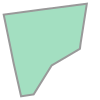

In [25]:
alameda.loc[0, 'geometry']

To view all of the polygons in a GeoDataFrame, we can just use the `plot` function. The documentation for this function is linked [here](http://geopandas.org/mapping.html)

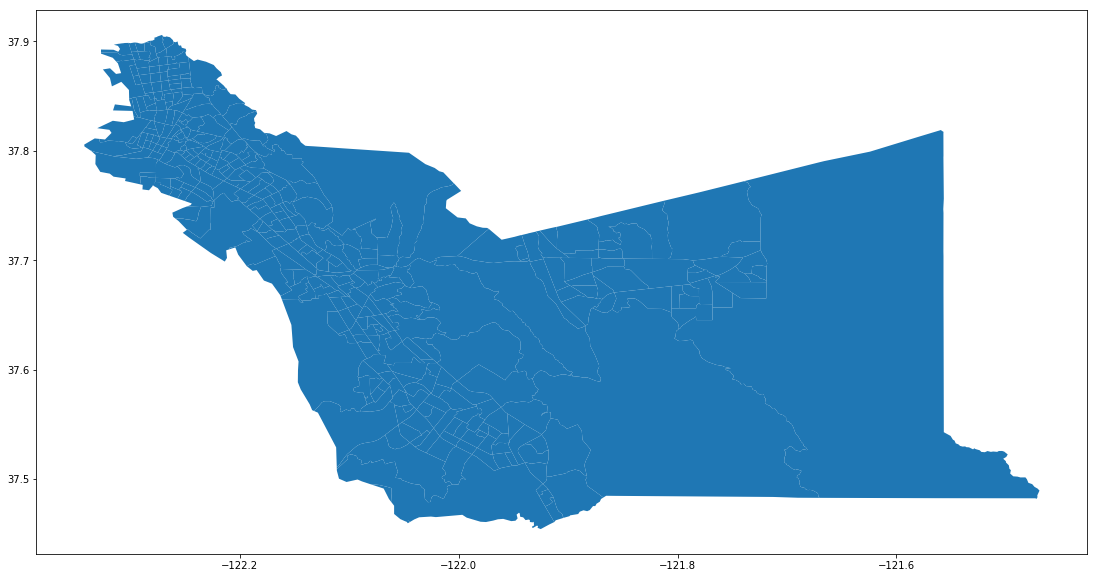

In [27]:
alameda.plot();

### Chloropleth maps

If we want to make this map more informative, we can incorporate some of the other columns from the data into the map.

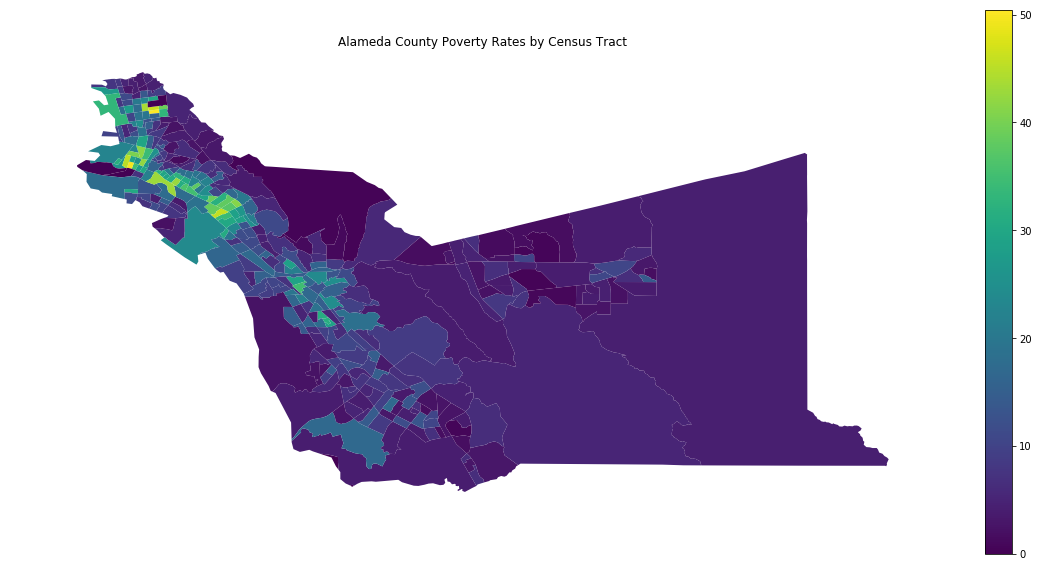

In [35]:
alameda.plot(column = 'pct_pov', legend = True)
plt.title('Alameda County Poverty Rates by Census Tract')
plt.axis('off');

### Creating a new shapefile

### Combining multiple datasets